## DETR Test Lab Nootebook

This notebook allows to test the base model and finetuned model of DETR

First load the model to CUDA and, with a given image, the model tries to generate the bounding boxes for only the match text.

The main purpose of this is to crop the base image with the generated boxes and pass the cropped images to the TROCR to recognize the text

In [1]:
from transformers import DetrForObjectDetection, DetrImageProcessor
import torch
import cv2
import supervision as sv

2024-08-29 11:47:28.954035: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-29 11:47:30.718046: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [8]:
MODEL_CHECKPOINT = "/home/ralvarez22/Documentos/trocr_hand/trocr_llm/finetuned/detr/Ena/V_4"
DEVICE = "cuda"
CONFIDENCE_TRESHOLD = 0.5 # This parameter allows to filter the generated boxes with a confidence score >= to this value
IOU_TRESHOLD = 0.5
TEST_IMAGE = "/home/ralvarez22/Documentos/trocr_hand/trocr_llm/demo/detr_ocr_demo.jpeg" # Path to the test image

In [3]:
img_proc = DetrImageProcessor.from_pretrained(MODEL_CHECKPOINT)
detr_model = DetrForObjectDetection.from_pretrained(
    pretrained_model_name_or_path=MODEL_CHECKPOINT,
    num_queries=100,
    ignore_mismatched_sizes=True
).to(DEVICE)


In [9]:
# Get the pixel values of the image (matrix)
image = cv2.imread(TEST_IMAGE)

In [10]:
# inference
with torch.no_grad():

    # load image and predict
    inputs = img_proc(images=image, return_tensors='pt').to(DEVICE)
    outputs = detr_model(**inputs)

    # post-process
    # Resize the generated Bounding Boxes coords to the image original size
    target_sizes = torch.tensor([image.shape[:2]]).to(DEVICE)
    results = img_proc.post_process_object_detection(
        outputs=outputs, 
        threshold=CONFIDENCE_TRESHOLD, 
        target_sizes=target_sizes
    )[0]

In [11]:
len(results["boxes"])

53

detections


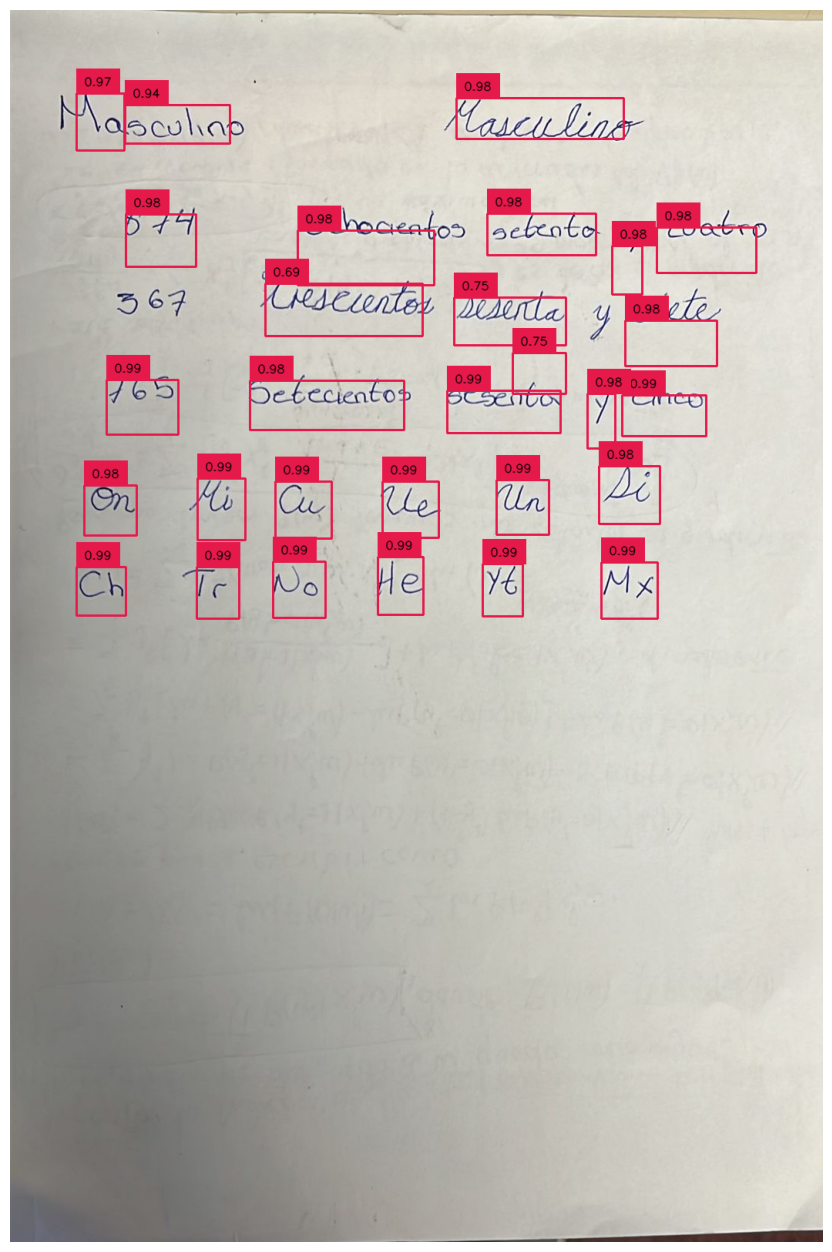

: 

In [12]:
# With supervision lib, use the generated coords to annotate the image and preview the boxes
box_annotator = sv.BoxAnnotator()
detections = sv.Detections.from_transformers(transformers_results=results).with_nms(threshold=0.1)
labels = [f"{confidence:.2f}" for _,_, confidence, class_id, _ in detections]
frame = box_annotator.annotate(scene=image.copy(), detections=detections, labels=labels)

print('detections')
%matplotlib inline  
sv.plot_image(frame, (16, 16))